In [1]:
# Imports!

import numpy as np 
import matplotlib.pyplot as plt
import nibabel as nib
import sys
import os

sys.path.append(os.path.abspath("../src"))
from denoising.figures.VisualizeSpectra_Fig2 import *
from denoising.figures.MetabMapsWithError_Fig3 import *
from denoising.eval.simulations import *
from denoising.figures.rRMSE_Fig4etc import *

# Compare spectra (paper Fig. 2)

## Compare simulated spectra

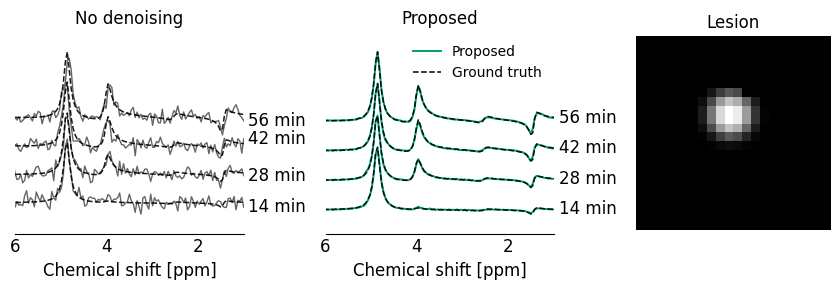

In [2]:
GT = np.load("MetabMaps/Lesion_Double_GT/Spectra_Lesion_Double_GT.npy")[...,:166,:] # cropped to 1 to 8 ppm instead of 0.5 to 8
Proposed = np.load("MetabMaps/Lesion_double_deep_tmppca_1/Spectra_Lesion_double_deep_tmppca_1.npy")[...,:166,:]
tMPPCA = np.load("MetabMaps/Lesion_double_tmppca_1/Spectra_Lesion_double_tmppca_1.npy")[...,:166,:]
Noisy = np.load("MetabMaps/Lesion_double_noisy_1/Spectra_Lesion_double_noisy_1.npy")[...,:166,:]

# Note: The way this is loaded above makes sure that the indices match exactly what you see in freeview

Glx = np.load("MetabMaps/Lesion_Double_GT/Glx_amp_Lesion_Double_GT_Orig.npy")
Glx = np.flip(np.flip(np.swapaxes(Glx, 0, 2), 0), 1) # this is now exactly oriented as in freeview, with exakt same indices as shown in freeview

# Läsionsmaske
nii = nib.load("other/Lesion_Double_lr.nii")          # oder .nii.gz
Lesion = nii.get_fdata()              # numpy array (float)

ppm = np.linspace(8, 1, 166)

fig, axs = plot_noisy_vs_methods(
    Noisy,
    Proposed,
    Method2=GT,  # GT dashed overlay in BOTH panels now
    ppm=ppm,
    x=14, y=11, z=15,
    t_idx=[0, 2, 4, 6],
    time_labels=["14 min", "28 min", "42 min", "56 min"],
    titles=("No denoising", "Proposed"),
    anatomy=Lesion[..., 15],
    anatomy_title="Lesion",
)

plt.savefig("SavedGraphics/SpectraSim.pdf", bbox_inches="tight")
plt.show()

## Compare in vivo (healthy) spectra

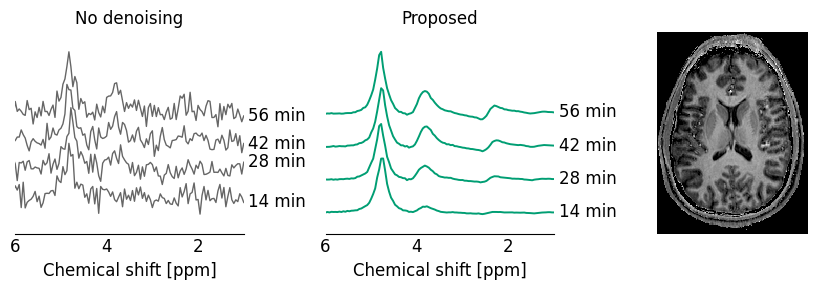

In [3]:
Proposed = np.load("MetabMaps/P08_deep_tMPPCA_5D/Spectra_P08_deep_tMPPCA_5D.npy")[...,:162,:]#[...,:166,:]
Noisy = np.load("MetabMaps/P08_noisy/Spectra_P08_noisy.npy")[...,:162,:]
Anatomy = np.flip(np.swapaxes(load_nifti_ras("other/magnitudeP08.nii"), 0, 1), axis=0)

ppm = np.linspace(8, 1, 162)

fig, axs = plot_noisy_vs_methods(
    Noisy,
    Proposed,
    #Method2=GT,          # dashed overlay
    ppm=ppm,
    x=8, y=11, z=11,
    t_idx=[0, 2, 4, 6],
    time_labels=["14 min", "28 min", "42 min", "56 min"],
    titles=("No denoising", "Proposed"),
    anatomy = Anatomy[..., 106],
    anatomy_clim=(1268, 3619),
    #linestyles=("-", "--")
)
plt.savefig("SavedGraphics/SpectraHealthy.pdf", bbox_inches="tight")
plt.show()

## Compare in vivo (tumor) spectra

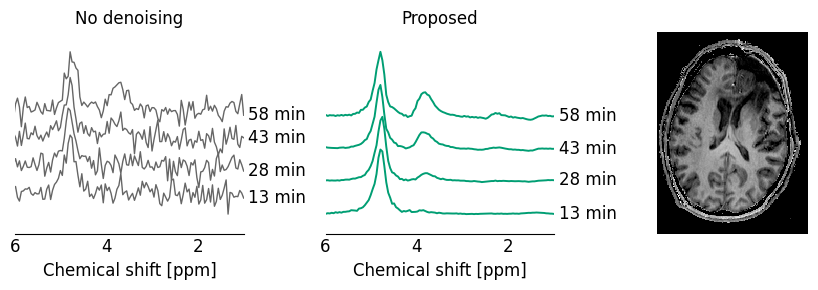

In [4]:
Noisy = np.load("MetabMaps/Tumor_1_noisy/Spectra_Tumor_1_noisy.npy")#[...,:166,:] schneide 2 ppm weg also von 6 bis 1ppm 
Proposed = np.load("MetabMaps/Tumor_1_deep_tMPPCA_5D/Spectra_Tumor_1_deep_tMPPCA_5D.npy")
Tumor = np.flip(np.swapaxes(load_nifti_ras("other/magnitudeTumor1.nii"), 0, 1), 0)

ppm = np.linspace(8, 1, 165)

fig, axs = plot_noisy_vs_methods(
    Noisy,
    Proposed,
    #Method2=GT,          # dashed overlay
    ppm=ppm,
    x=13, y=15, z=11,
    t_idx=[0, 3, 6, 9],
    time_labels=["13 min", "28 min", "43 min", "58 min"],
    titles=("No denoising", "Proposed"),
    anatomy = Tumor[..., 113],
    anatomy_clim=(1268, 3619),
    #linestyles=("-", "--")
)

plt.savefig("SavedGraphics/SpectraTumor.pdf", bbox_inches="tight")
plt.show()

# Fig. 3 Comparison of Metab Maps

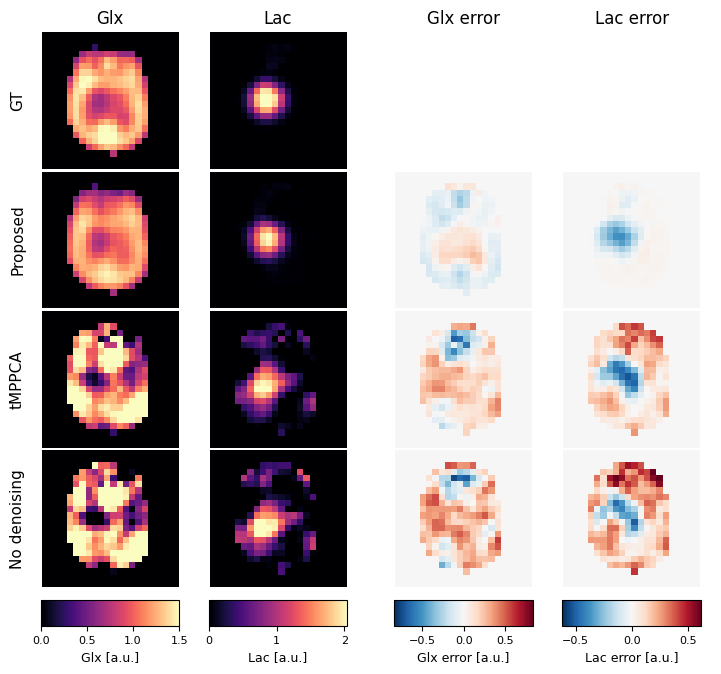

In [5]:
t_idx = 3  # repetition
z_idx = 11 

nii = nib.load("Segmentations/mask_lr.nii")  # oder .nii.gz
data = nii.get_fdata()          # -> numpy array (float64)
mask = (data > 0) & np.isfinite(data)

methods = ["GT", "Proposed", "tMPPCA", "No denoising"]

Noisy_Reps  = ["Lesion_double_noisy_1", "Lesion_double_noisy_2", "Lesion_double_noisy_3", "Lesion_double_noisy_4", "Lesion_double_noisy_5", "Lesion_double_noisy_6"]
Deep_Reps   = ["Lesion_double_deep_tmppca_1", "Lesion_double_deep_tmppca_2", "Lesion_double_deep_tmppca_3", "Lesion_double_deep_tmppca_4", "Lesion_double_deep_tmppca_5", "Lesion_double_deep_tmppca_6"]
tMPPCA_Reps = ["Lesion_double_tmppca_1", "Lesion_double_tmppca_2", "Lesion_double_tmppca_3", "Lesion_double_tmppca_4", "Lesion_double_tmppca_5", "Lesion_double_tmppca_6"]

maps = {
  "GT": {
    "Glx": load_metab_map("MetabMaps", "Lesion_Double_GT", "Glx", suffix="Orig"),
    "Lac": load_metab_map("MetabMaps", "Lesion_Double_GT", "Lac", suffix="Orig"),
  },
  "No denoising": {
    "Glx": load_metab_map("MetabMaps", Noisy_Reps[0], "Glx", suffix="Orig"),
    "Lac": load_metab_map("MetabMaps", Noisy_Reps[0], "Lac", suffix="Orig"),
  },
  "tMPPCA": {
    "Glx": load_metab_map("MetabMaps", tMPPCA_Reps[0], "Glx", suffix="Orig"),
    "Lac": load_metab_map("MetabMaps", tMPPCA_Reps[0], "Lac", suffix="Orig"),
  },
  "Proposed": {
    "Glx": load_metab_map("MetabMaps", Deep_Reps[0], "Glx", suffix="Orig"),
    "Lac": load_metab_map("MetabMaps", Deep_Reps[0], "Lac", suffix="Orig"),
  },
}

# errors: mean across reps for each method
err_noisy_glx, _  = error_mean_var_for_methods("MetabMaps", Noisy_Reps,  "Glx", "Lesion_Double_GT", suffix="Orig", mean_over_time=False)
err_tmppca_glx, _ = error_mean_var_for_methods("MetabMaps", tMPPCA_Reps, "Glx", "Lesion_Double_GT", suffix="Orig", mean_over_time=False)
err_deep_glx, _   = error_mean_var_for_methods("MetabMaps", Deep_Reps,   "Glx", "Lesion_Double_GT", suffix="Orig", mean_over_time=False)

err_noisy_lac, _  = error_mean_var_for_methods("MetabMaps", Noisy_Reps,  "Lac", "Lesion_Double_GT", suffix="Orig", mean_over_time=False)
err_tmppca_lac, _ = error_mean_var_for_methods("MetabMaps", tMPPCA_Reps, "Lac", "Lesion_Double_GT", suffix="Orig", mean_over_time=False)
err_deep_lac, _   = error_mean_var_for_methods("MetabMaps", Deep_Reps,   "Lac", "Lesion_Double_GT", suffix="Orig", mean_over_time=False)

errs = {
  "GT": {"Glx": None, "Lac": None},  # unused
  "No denoising": {"Glx": err_noisy_glx, "Lac": err_noisy_lac},
  "tMPPCA": {"Glx": err_tmppca_glx, "Lac": err_tmppca_lac},
  "Proposed": {"Glx": err_deep_glx, "Lac": err_deep_lac},
}

_ = plot_sim_maps_with_per_column_cbars(
    maps, errs,
    t_idx=t_idx, z_idx=z_idx,
    methods=("GT", "Proposed", "tMPPCA", "No denoising"),
    metabolites=("Glx", "Lac"),
    title=None,
    save_path="SavedGraphics/Fig3_simulationMaps.pdf",
    show=True
)

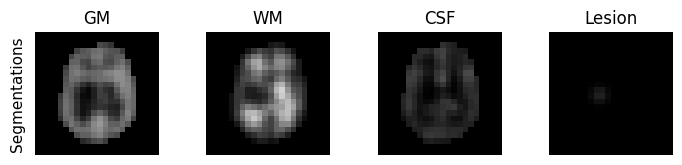

In [6]:
import nibabel as nib
import numpy as np

mask2 = mask  # (X,Y,Z) 0/1

GM  = nib.load("Segmentations/GM_lr.nii").get_fdata().astype(np.float32) * mask2
WM  = nib.load("Segmentations/WM_lr.nii").get_fdata().astype(np.float32) * mask2
CSF = nib.load("Segmentations/CSF_lr.nii").get_fdata().astype(np.float32) * mask2
LES = nib.load("Segmentations/Lesion_lr.nii").get_fdata().astype(np.float32) * mask2

segs = {"GM": GM, "WM": WM, "CSF": CSF, "Lesion": LES}

_ = plot_segmentation_row(
    segs,
    z_idx=11,
    save_path="SavedGraphics/segmentations_row.pdf",
    show=True
)

# Fig. 4: Time resolved RMSE Big Lesion

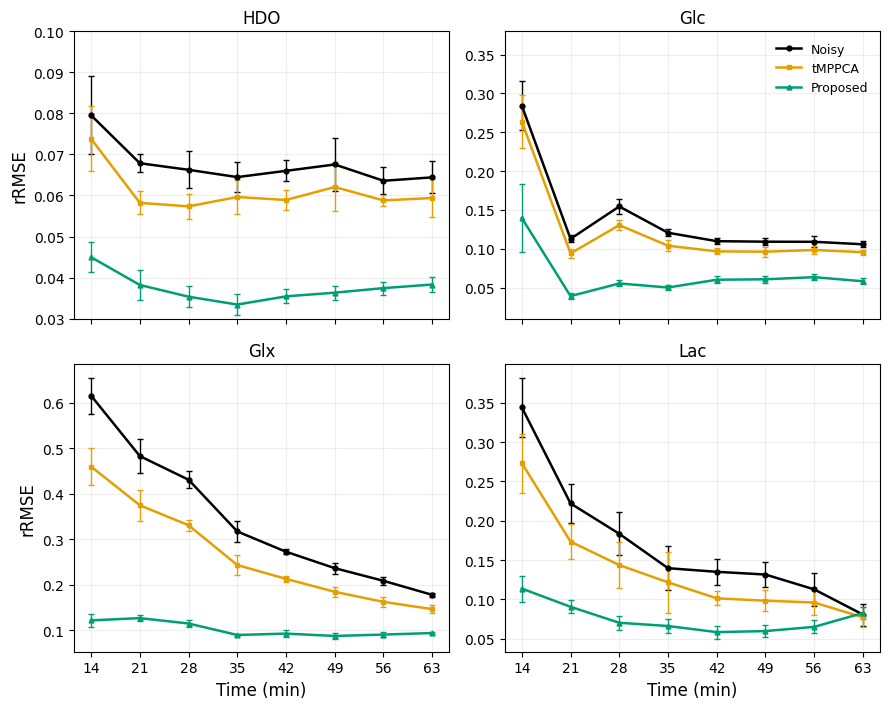

In [7]:
nii = nib.load("Segmentations/mask_lr.nii")  # oder .nii.gz
brain_mask = nii.get_fdata()         # -> numpy array (float64)

nii = nib.load("Segmentations/Lesion_Double_lr.nii")
Lesion_mask = nii.get_fdata()

# --- reproduce the 3-method figure (Noisy, tMPPCA, Proposed) with error bars ---

root = "MetabMaps"
gt_method = "Lesion_Double_GT"
suffix = "Orig"

Noisy_Reps  = [
    "Lesion_double_noisy_1", "Lesion_double_noisy_2", "Lesion_double_noisy_3",
    "Lesion_double_noisy_4", "Lesion_double_noisy_5", "Lesion_double_noisy_6"
]
Deep_Reps   = [
    "Lesion_double_deep_tmppca_1", "Lesion_double_deep_tmppca_2",
    "Lesion_double_deep_tmppca_3", "Lesion_double_deep_tmppca_4",
    "Lesion_double_deep_tmppca_5", "Lesion_double_deep_tmppca_6"
]
tMPPCA_Reps = [
    "Lesion_double_tmppca_1", "Lesion_double_tmppca_2", "Lesion_double_tmppca_3",
    "Lesion_double_tmppca_4", "Lesion_double_tmppca_5", "Lesion_double_tmppca_6"
]

rep_methods = {
    "Noisy":    Noisy_Reps,
    "tMPPCA":   tMPPCA_Reps,
    "Proposed": Deep_Reps,
}

metabs = [
    ("water", brain_mask),
    ("Glc",   brain_mask),
    ("Glx",   brain_mask),
    ("Lac",   Lesion_mask),
]

DISPLAY_NAME = {"water":"HDO","Glc":"Glc","Glx":"Glx","Lac":"Lac"}
time_axis = np.array([14, 21, 28, 35, 42, 49, 56, 63])

method_style = {
    "Noisy":    {"color":"#000000", "marker":"o", "linestyle":"-", "use_errorbar": True, "label":"Noisy"},
    "tMPPCA":   {"color":"#E69F00", "marker":"s", "linestyle":"-", "use_errorbar": True, "label":"tMPPCA"},
    "Proposed": {"color":"#009E73", "marker":"^", "linestyle":"-", "use_errorbar": True, "label":"Proposed"},
}

ylims = {
    "water": (0.03, 0.10),
    "Glc":   (0.01, 0.38),
}

_ = plot_rrmse_2x2(
    root=root,
    gt_method=gt_method,
    suffix=suffix,
    metabs=metabs,
    display_name=DISPLAY_NAME,
    time_axis=time_axis,
    rep_methods=rep_methods,
    method_style=method_style,
    ylabel_left="rRMSE",
    ylims=ylims,
    save_path="SavedGraphics/rrmse_timecourse_2x2_BigLesion.pdf",
    show=True
)



# Fig. 9: Time resolved rRMSE small Lesion

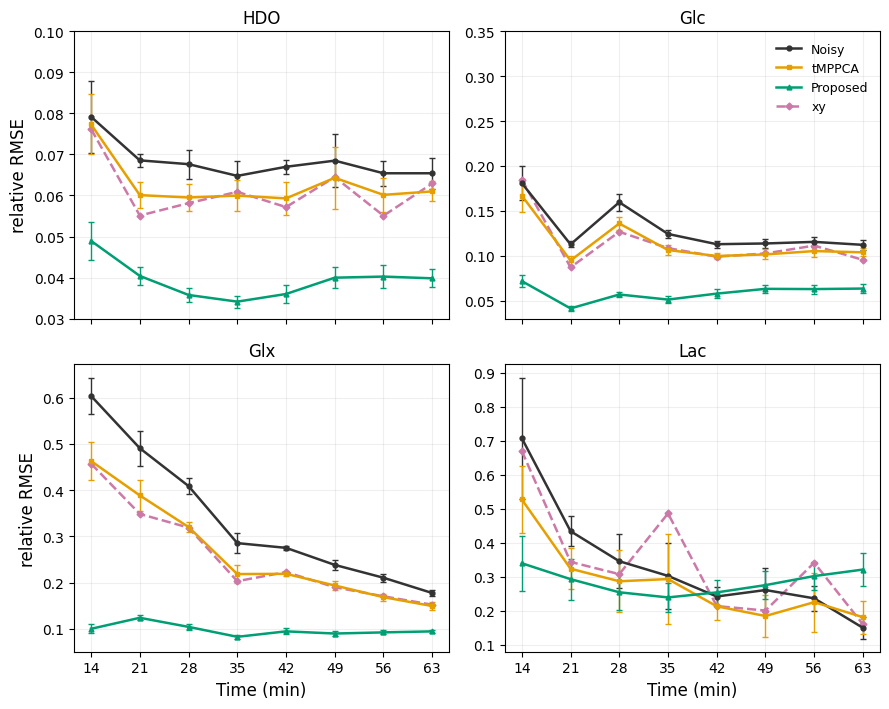

In [8]:
nii = nib.load("Segmentations/mask_lr.nii")  # oder .nii.gz
brain_mask = nii.get_fdata()         # -> numpy array (float64)

nii = nib.load("Segmentations/Lesion_lr.nii")
Lesion_mask = nii.get_fdata()

# ---------- SETTINGS ----------
root = "MetabMaps"
gt_method = "Lesion_GT"
suffix = "Orig"

Noisy_Reps  = ["Lesion_noisy_1","Lesion_noisy_2","Lesion_noisy_3","Lesion_noisy_4","Lesion_noisy_5","Lesion_noisy_6"]
Deep_Reps   = ["Lesion_deep_tmppca_1","Lesion_deep_tmppca_2","Lesion_deep_tmppca_3","Lesion_deep_tmppca_4","Lesion_deep_tmppca_5","Lesion_deep_tmppca_6"]
tMPPCA_Reps = ["Lesion_tmppca_1","Lesion_tmppca_2","Lesion_tmppca_3","Lesion_tmppca_4","Lesion_tmppca_5","Lesion_tmppca_6"]
xy_Reps     = ["Lesion_tmppca_6"]  # single

rep_methods = {
    "Noisy":    Noisy_Reps,
    "tMPPCA":   tMPPCA_Reps,
    "Proposed": Deep_Reps,
    "xy":       xy_Reps,
}

metabs = [
    ("water", brain_mask),
    ("Glc",   brain_mask),
    ("Glx",   brain_mask),
    ("Lac",   Lesion_mask),
]

DISPLAY_NAME = {"water":"HDO","Glc":"Glc","Glx":"Glx","Lac":"Lac"}
time_axis = np.array([14, 21, 28, 35, 42, 49, 56, 63])

# --- unified style (colors/markers like in your snippet) ---
method_style = {
    "Noisy":    {"color":"#333333", "marker":"o", "linestyle":"-",  "use_errorbar": True,  "label":"Noisy"},
    "tMPPCA":   {"color":"#E69F00", "marker":"s", "linestyle":"-",  "use_errorbar": True,  "label":"tMPPCA"},
    "Proposed": {"color":"#009E73", "marker":"^", "linestyle":"-",  "use_errorbar": True,  "label":"Proposed"},
    "xy":       {"color":"#CC79A7", "marker":"D", "linestyle":"--", "use_errorbar": False, "label":"xy"},
}

ylims = {"water": (0.03, 0.10), "Glc": (0.03, 0.35)}

_ = plot_rrmse_2x2(
    root=root, gt_method=gt_method, suffix=suffix,
    metabs=metabs, display_name=DISPLAY_NAME, time_axis=time_axis,
    rep_methods=rep_methods, method_style=method_style,
    ylabel_left="relative RMSE",
    ylims=ylims,
    save_path="SavedGraphics/rrmse_timecourse_2x2_SmallLesion.pdf",
    show=True
)

# Fig. 10 Big Lesion w/o noise correlations

/workspace/Denoising/src/denoising/figures/rRMSE_Fig4etc.py:346: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


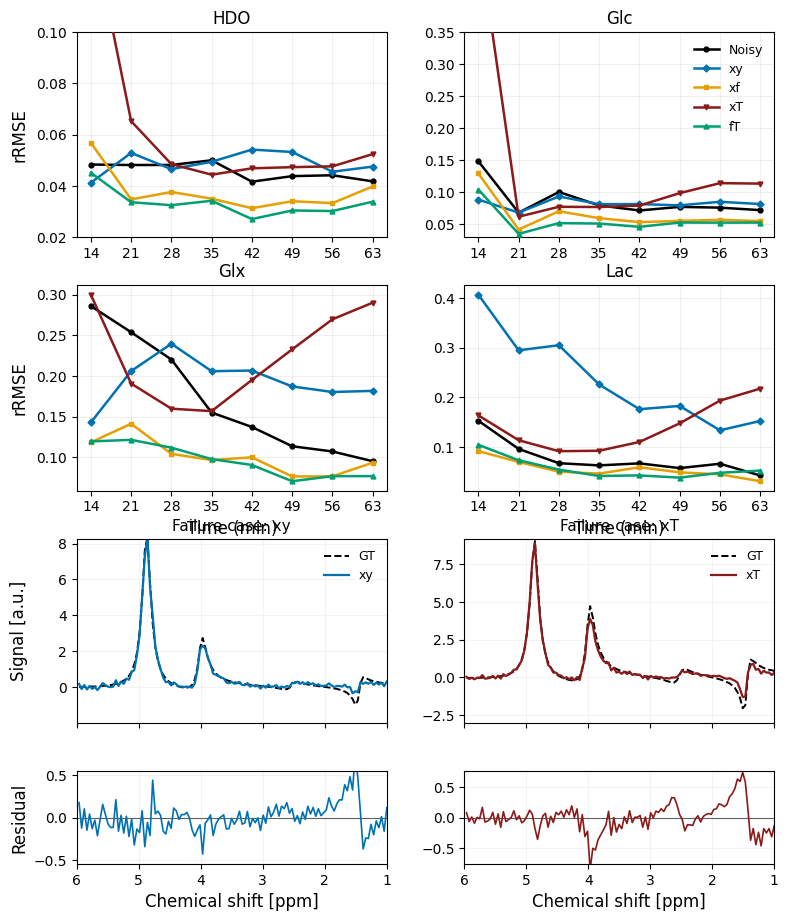

In [9]:
nii = nib.load("Segmentations/mask_lr.nii")  # oder .nii.gz
brain_mask = nii.get_fdata()         # -> numpy array (float64)

nii = nib.load("Segmentations/Lesion_Double_lr.nii")
Lesion_mask = nii.get_fdata()

import numpy as np 
import matplotlib.pyplot as plt

GT = np.load("MetabMaps/Lesion_Double_GT/Spectra_Lesion_Double_GT.npy")[...,:166,:] # cropped to 1 to 8 ppm instead of 0.5 to 8
xy = np.load("MetabMaps/Lesion_double_deep_xy_6_uncorrelated/Spectra_Lesion_double_deep_xy_6_uncorrelated.npy")[...,:166,:]
xT = np.load("MetabMaps/Lesion_double_deep_xT_6_uncorrelated/Spectra_Lesion_double_deep_xT_6_uncorrelated.npy")[...,:166,:]
xf = np.load("MetabMaps/Lesion_double_deep_xf_6_uncorrelated/Spectra_Lesion_double_deep_xf_6_uncorrelated.npy")[...,:166,:]
fT = np.load("MetabMaps/Lesion_double_deep_fT_6_uncorrelated/Spectra_Lesion_double_deep_fT_6_uncorrelated.npy")[...,:166,:]

# ---------- SETTINGS ----------
root = "MetabMaps"
gt_method = "Lesion_Double_GT"
suffix = "Orig"

Noisy_Reps = ["Lesion_double_noisy_6_uncorrelated"]
xy_Reps    = ["Lesion_double_deep_xy_6_uncorrelated"]
xf_Reps    = ["Lesion_double_deep_xf_6_uncorrelated"]
xT_Reps    = ["Lesion_double_deep_xT_6_uncorrelated"]
fT_Reps    = ["Lesion_double_deep_fT_6_uncorrelated"]

rep_methods = {
    "Noisy": Noisy_Reps,
    "xy":    xy_Reps,
    "xf":    xf_Reps,
    "xT":    xT_Reps,
    "fT":    fT_Reps,
}

DISPLAY_METHOD = {
    "Noisy": "Noisy",
    "xy":    "xy",
    "xf":    "xf",
    "xT":    "xT",
    "fT":    "fT",
}

metabs = [
    ("water", brain_mask),
    ("Glc",   brain_mask),
    ("Glx",   brain_mask),
    ("Lac",   Lesion_mask),
]

DISPLAY_NAME = {
    "water": "HDO",
    "Glc":   "Glc",
    "Glx":   "Glx",
    "Lac":   "Lac",
}

time_axis = np.array([14, 21, 28, 35, 42, 49, 56, 63])

# ===================== PLOTTING =====================

DEFAULT_COLORS = {
    "Noisy": "#000000",   # black
    "xy":    "#0072B2",   # blue
    "xf":    "#E69F00",   # green  009E73
    "xT":    "#8B1A1A",   # dark red
    "fT":    "#009E73",   # orange "#E69F00
}

DEFAULT_MARKERS = {
    "Noisy": "o",
    "xy":    "D",
    "xf":    "s",
    "xT":    "v",
    "fT":    "^",
}

ylims = {"water": (0.02, 0.10), "Glc": (0.03, 0.35)}

_ = plot_combined_rrmse_and_failure_cases(
    root=root,
    gt_method=gt_method,
    suffix=suffix,
    rep_methods=rep_methods,
    display_method=DISPLAY_METHOD,
    metabs=metabs,
    display_name=DISPLAY_NAME,
    time_axis=time_axis,
    default_colors=DEFAULT_COLORS,
    default_markers=DEFAULT_MARKERS,
    GT=GT,
    xy=xy,
    xT=xT,
    x=14, y=11, z=15,
    t_left=2,
    t_right=7,
    ylims=ylims, 
    save_path="SavedGraphics/Combined_rRMSE_plus_FailureCases.pdf",
    show=True
)